In [227]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [228]:
import itertools
import seaborn as sns
import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices


In [229]:
from sklearn import datasets
from sklearn.feature_selection import RFE
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

In [230]:
import pandas as pd
train = pd.read_csv("KDDTrain.csv",sep=',')
test = pd.read_csv("KDDTest.csv",sep=',')


In [231]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [232]:
train.tail()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125972,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal,21


In [233]:
columns=["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
         "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations", 
         "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
         "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
         "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
         "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
         "dst_host_srv_rerror_rate","attack","last_flag"] 

In [234]:
len(columns)

43

In [235]:
train.columns=columns
test.columns=columns

In [236]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [237]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [238]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [239]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  str    
 2   service                      22544 non-null  str    
 3   flag                         22544 non-null  str    
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell                 

In [240]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [241]:
#In attack_class normal means 0, DOS means 1, PROBE means 2, R2L means 3 and U2R means 4.
train.loc[train.attack=='normal','attack_class']=0

train.loc[(train.attack=='back') | (train.attack=='land') | (train.attack=='pod') | (train.attack=='neptune') | 
         (train.attack=='smurf') | (train.attack=='teardrop') | (train.attack=='apache2') | (train.attack=='udpstorm') | 
         (train.attack=='processtable') | (train.attack=='worm') | (train.attack=='mailbomb'),'attack_class']=1

train.loc[(train.attack=='satan') | (train.attack=='ipsweep') | (train.attack=='nmap') | (train.attack=='portsweep') | 
          (train.attack=='mscan') | (train.attack=='saint'),'attack_class']=2

train.loc[(train.attack=='guess_passwd') | (train.attack=='ftp_write') | (train.attack=='imap') | (train.attack=='phf') | 
          (train.attack=='multihop') | (train.attack=='warezmaster') | (train.attack=='warezclient') | (train.attack=='spy') | 
          (train.attack=='xlock') | (train.attack=='xsnoop') | (train.attack=='snmpguess') | (train.attack=='snmpgetattack') | 
          (train.attack=='httptunnel') | (train.attack=='sendmail') | (train.attack=='named'),'attack_class']=3

train.loc[(train.attack=='buffer_overflow') | (train.attack=='loadmodule') | (train.attack=='rootkit') | (train.attack=='perl') | 
          (train.attack=='sqlattack') | (train.attack=='xterm') | (train.attack=='ps'),'attack_class']=4

In [242]:
test.loc[test.attack=='normal','attack_class']=0

test.loc[(test.attack=='back') | (test.attack=='land') | (test.attack=='pod') | (test.attack=='neptune') | 
         (test.attack=='smurf') | (test.attack=='teardrop') | (test.attack=='apache2') | (test.attack=='udpstorm') | 
         (test.attack=='processtable') | (test.attack=='worm') | (test.attack=='mailbomb'),'attack_class']=1

test.loc[(test.attack=='satan') | (test.attack=='ipsweep') | (test.attack=='nmap') | (test.attack=='portsweep') | 
          (test.attack=='mscan') | (test.attack=='saint'),'attack_class']=2

test.loc[(test.attack=='guess_passwd') | (test.attack=='ftp_write') | (test.attack=='imap') | (test.attack=='phf') | 
          (test.attack=='multihop') | (test.attack=='warezmaster') | (test.attack=='warezclient') | (test.attack=='spy') | 
          (test.attack=='xlock') | (test.attack=='xsnoop') | (test.attack=='snmpguess') | (test.attack=='snmpgetattack') | 
          (test.attack=='httptunnel') | (test.attack=='sendmail') | (test.attack=='named'),'attack_class']=3

test.loc[(test.attack=='buffer_overflow') | (test.attack=='loadmodule') | (test.attack=='rootkit') | (test.attack=='perl') | 
          (test.attack=='sqlattack') | (test.attack=='xterm') | (test.attack=='ps'),'attack_class']=4

In [243]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag,attack_class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0.0


In [244]:
train.shape

(125973, 44)

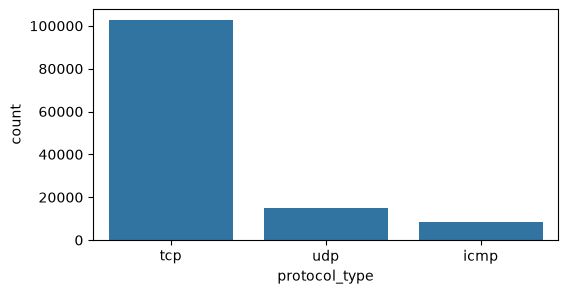

In [245]:
# Protocol type distribution
plt.figure(figsize=(6,3))
sns.countplot(x="protocol_type", data=train)
plt.show()


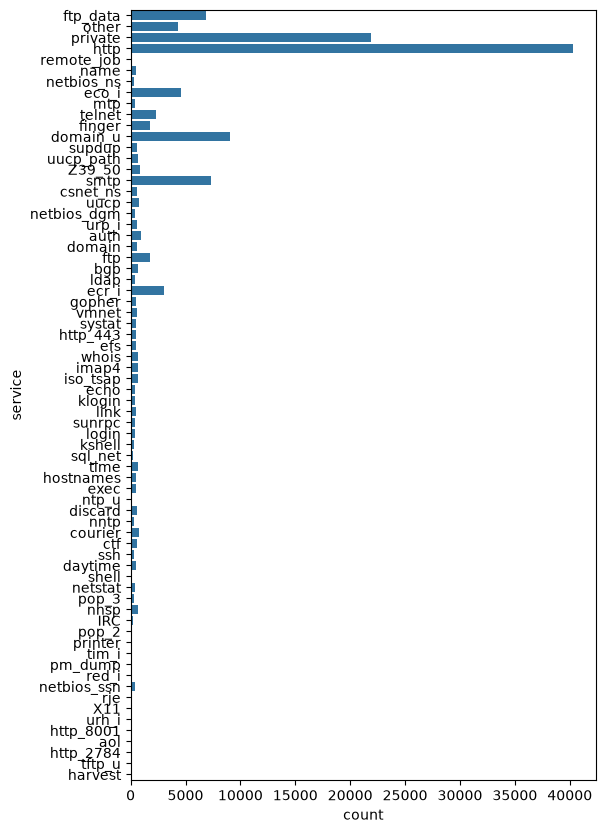

In [246]:
# service distribution
plt.figure(figsize=(6,10))
sns.countplot(y="service", data=train)
plt.show()

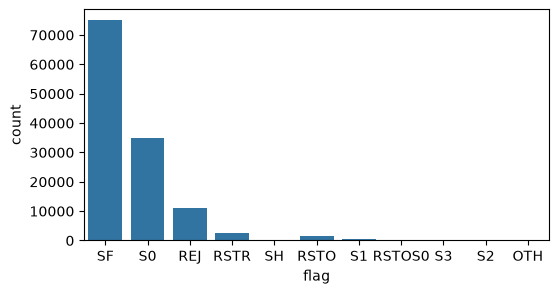

In [247]:
# flag distribution
plt.figure(figsize=(6,3))
sns.countplot(x="flag", data=train)
plt.show()

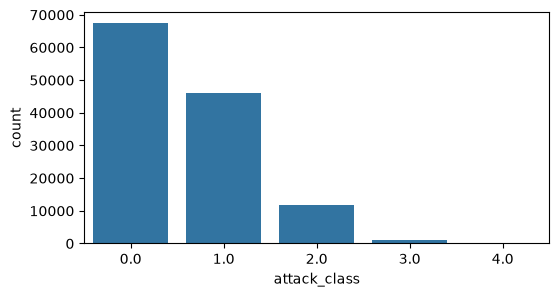

In [248]:
# attack class distribution
plt.figure(figsize=(6,3))
sns.countplot(x="attack_class", data=train)
plt.show()


In [249]:
# Select only numerical columns
numeric_cols = train.select_dtypes(include='number')

# Group by attack_class and calculate mean
mean_values = numeric_cols.groupby(train['attack_class']).mean().T

print(mean_values)


attack_class                          0.0          1.0            2.0  \
duration                       168.587396     0.006227    2074.858185   
src_bytes                    13133.279331  1176.321162  385679.838367   
dst_bytes                     4329.685223   169.201537  181074.911805   
land                             0.000104     0.000392       0.000000   
wrong_fragment                   0.000000     0.062229       0.000000   
urgent                           0.000148     0.000000       0.000000   
hot                              0.230655     0.039889       0.001630   
num_failed_logins                0.001381     0.000000       0.000343   
logged_in                        0.710646     0.020837       0.007121   
num_compromised                  0.507076     0.019226       0.000601   
root_shell                       0.002034     0.000000       0.000000   
su_attempted                     0.002049     0.000000       0.000000   
num_root                         0.562924     0.000

In [250]:
numeric_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
cat_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['object', 'O']]

In [251]:
numeric_var_names

['duration',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'last_flag',
 'attack_class']

In [252]:
cat_var_names

[]

In [253]:
train_num=train[numeric_var_names]
test_num=test[numeric_var_names]
train_num.head(5)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,last_flag,attack_class
0,0,491,0,0,0,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,20,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,15,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,19,1.0
3,0,232,8153,0,0,0,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,21,0.0
4,0,199,420,0,0,0,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21,0.0


In [254]:
train_cat = train[cat_var_names]
test_cat = test[cat_var_names]

#Data Audit Report

In [255]:
# Creating Data audit Report
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()], 
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])

num_summary=train_num.apply(lambda x: var_summary(x)).T

In [256]:
num_summary

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,MIN,P1,P5,P10,P25,P50,P75,P90,P95,P99,MAX
duration,125973.0,0.0,3.617247e+07,287.144650,0.00,2.604515e+03,6.783500e+06,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,4.00,9590.56,4.290800e+04
src_bytes,125973.0,0.0,5.740179e+09,45566.743000,44.00,5.870331e+06,3.446079e+13,0.0,0.0,0.00,0.00,0.00,44.00,276.00,848.00,1480.00,54540.00,1.379964e+09
dst_bytes,125973.0,0.0,2.491634e+09,19779.114421,0.00,4.021269e+06,1.617061e+13,0.0,0.0,0.00,0.00,0.00,0.00,516.00,3375.80,8314.00,25519.00,1.309937e+09
land,125973.0,0.0,2.500000e+01,0.000198,0.00,1.408607e-02,1.984174e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.0,2.858000e+03,0.022687,0.00,2.535300e-01,6.427745e-02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.0,1.400000e+01,0.000111,0.00,1.436603e-02,2.063827e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.0,2.575000e+04,0.204409,0.00,2.149968e+00,4.622364e+00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,7.700000e+01
num_failed_logins,125973.0,0.0,1.540000e+02,0.001222,0.00,4.523914e-02,2.046580e-03,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.0,4.985200e+04,0.395736,0.00,4.890101e-01,2.391308e-01,0.0,0.0,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.000000e+00
num_compromised,125973.0,0.0,3.517800e+04,0.279250,0.00,2.394204e+01,5.732214e+02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,7.479000e+03


In [257]:
num_summary.to_csv('num_summary.csv')

In [258]:
#Handling Outlier

In [259]:
#Handling Outliers
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

train_num=train_num.apply(outlier_capping)

In [260]:
#No missing in train dataset . So , Missing treatment not required .

In [261]:
def cat_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.value_counts()], 
                  index=['N', 'NMISS', 'ColumnsNames'])

cat_summary=train_cat.apply(cat_summary)

In [262]:
cat_summary

""
0
1
2
3
4
...
125968
125969
125970
125971


In [263]:
#Dummy Variable Creation

In [264]:
# An utility function to create dummy variable
def create_dummies( df, colname ):
    col_dummies = pd.get_dummies(df[colname], prefix=colname, drop_first=True)
    df = pd.concat([df, col_dummies], axis=1)
    df.drop( colname, axis = 1, inplace = True )
    return(df)

In [265]:
import pandas as pd
import numpy as np

# 1. Load the data
train = pd.read_csv("KDDTrain.csv", sep=',')
test = pd.read_csv("KDDTest.csv", sep=',')

# 2. Assign the column names
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
           "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations", 
           "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
           "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
           "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
           "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
           "dst_host_srv_rerror_rate","attack","last_flag"]
train.columns = columns
test.columns = columns

# 3. Map the attack classes
train.loc[train.attack=='normal','attack_class'] = 0
train.loc[(train.attack=='back') | (train.attack=='land') | (train.attack=='pod') | (train.attack=='neptune') | 
         (train.attack=='smurf') | (train.attack=='teardrop') | (train.attack=='apache2') | (train.attack=='udpstorm') | 
         (train.attack=='processtable') | (train.attack=='worm') | (train.attack=='mailbomb'),'attack_class'] = 1
train.loc[(train.attack=='satan') | (train.attack=='ipsweep') | (train.attack=='nmap') | (train.attack=='portsweep') | 
          (train.attack=='mscan') | (train.attack=='saint'),'attack_class'] = 2
train.loc[(train.attack=='guess_passwd') | (train.attack=='ftp_write') | (train.attack=='imap') | (train.attack=='phf') | 
          (train.attack=='multihop') | (train.attack=='warezmaster') | (train.attack=='warezclient') | (train.attack=='spy') | 
          (train.attack=='xlock') | (train.attack=='xsnoop') | (train.attack=='snmpguess') | (train.attack=='snmpgetattack') | 
          (train.attack=='httptunnel') | (train.attack=='sendmail') | (train.attack=='named'),'attack_class'] = 3
train.loc[(train.attack=='buffer_overflow') | (train.attack=='loadmodule') | (train.attack=='rootkit') | (train.attack=='perl') | 
          (train.attack=='sqlattack') | (train.attack=='xterm') | (train.attack=='ps'),'attack_class'] = 4

# Apply the same mapping to the test set
test.loc[test.attack=='normal','attack_class'] = 0
test.loc[(test.attack=='back') | (test.attack=='land') | (test.attack=='pod') | (test.attack=='neptune') | 
         (test.attack=='smurf') | (test.attack=='teardrop') | (test.attack=='apache2') | (test.attack=='udpstorm') | 
         (test.attack=='processtable') | (test.attack=='worm') | (test.attack=='mailbomb'),'attack_class'] = 1
test.loc[(test.attack=='satan') | (test.attack=='ipsweep') | (test.attack=='nmap') | (test.attack=='portsweep') | 
          (test.attack=='mscan') | (test.attack=='saint'),'attack_class'] = 2
test.loc[(test.attack=='guess_passwd') | (test.attack=='ftp_write') | (test.attack=='imap') | (test.attack=='phf') | 
          (test.attack=='multihop') | (test.attack=='warezmaster') | (test.attack=='warezclient') | (test.attack=='spy') | 
          (test.attack=='xlock') | (test.attack=='xsnoop') | (test.attack=='snmpguess') | (test.attack=='snmpgetattack') | 
          (test.attack=='httptunnel') | (test.attack=='sendmail') | (test.attack=='named'),'attack_class'] = 3
test.loc[(test.attack=='buffer_overflow') | (test.attack=='loadmodule') | (test.attack=='rootkit') | (test.attack=='perl') | 
          (test.attack=='sqlattack') | (test.attack=='xterm') | (test.attack=='ps'),'attack_class'] = 4

# 4. Extract numeric columns and apply outlier capping
numeric_var_names = [key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
train_num = train[numeric_var_names]
test_num = test[numeric_var_names]

def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

train_num = train_num.apply(outlier_capping)

# 5. Safely handle all categorical variables using pd.get_dummies
cat_features = ['protocol_type', 'service', 'flag', 'attack']
train_cat = pd.get_dummies(train[cat_features], columns=cat_features, drop_first=True)
test_cat = pd.get_dummies(test[cat_features], columns=cat_features, drop_first=True)

# 6. Concatenate the final dataframes
train_new = pd.concat([train_num, train_cat], axis=1)
test_new = pd.concat([test_num, test_cat], axis=1)

# Success check
print(f"Final training dataset shape: {train_new.shape}")

Final training dataset shape: (125973, 143)


In [266]:
#Final file for analysis
train_new = pd.concat([train_num, train_cat], axis=1)
test_new = pd.concat([test_num, test_cat], axis=1)
train_new.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0.0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0.0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,0.0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,0.0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
4,0.0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False


In [267]:
# correlation matrix (ranges from 1 to -1)
corrm=train_new.corr()
corrm

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
duration,1.000000,0.011740,0.036892,NaN,NaN,NaN,0.021274,NaN,-0.064537,0.062081,...,-0.000757,-0.005534,0.408874,-0.000414,-0.023837,-0.020278,0.000605,-0.011691,0.037014,-0.001571
src_bytes,0.011740,1.000000,0.127827,NaN,NaN,NaN,0.379973,NaN,0.163275,0.603363,...,-0.000898,0.002845,-0.022114,-0.001067,-0.028784,-0.002928,-0.000555,-0.013779,0.047995,-0.002012
dst_bytes,0.036892,0.127827,1.000000,NaN,NaN,NaN,0.127002,NaN,0.422000,0.237363,...,0.010050,-0.014103,-0.053376,0.006873,-0.060373,-0.051675,-0.000156,-0.029791,-0.011541,0.064962
land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wrong_fragment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
attack_smurf,-0.020278,-0.002928,-0.051675,NaN,NaN,NaN,-0.020616,NaN,-0.118537,-0.014876,...,-0.000825,-0.005856,-0.022607,-0.001305,-0.025241,1.000000,-0.000584,-0.012370,-0.012356,-0.001846
attack_spy,0.000605,-0.000555,-0.000156,NaN,NaN,NaN,-0.000561,NaN,0.000850,-0.000405,...,-0.000022,-0.000159,-0.000615,-0.000036,-0.000687,-0.000584,1.000000,-0.000336,-0.000336,-0.000050
attack_teardrop,-0.011691,-0.013779,-0.029791,NaN,NaN,NaN,-0.011886,NaN,-0.068340,-0.008576,...,-0.000476,-0.003376,-0.013034,-0.000752,-0.014552,-0.012370,-0.000336,1.000000,-0.007123,-0.001064
attack_warezclient,0.037014,0.047995,-0.011541,NaN,NaN,NaN,0.270177,NaN,0.104233,-0.008567,...,-0.000475,-0.003372,-0.013019,-0.000752,-0.014536,-0.012356,-0.000336,-0.007123,1.000000,-0.001063


In [268]:
corrm.to_csv('corrm.csv')

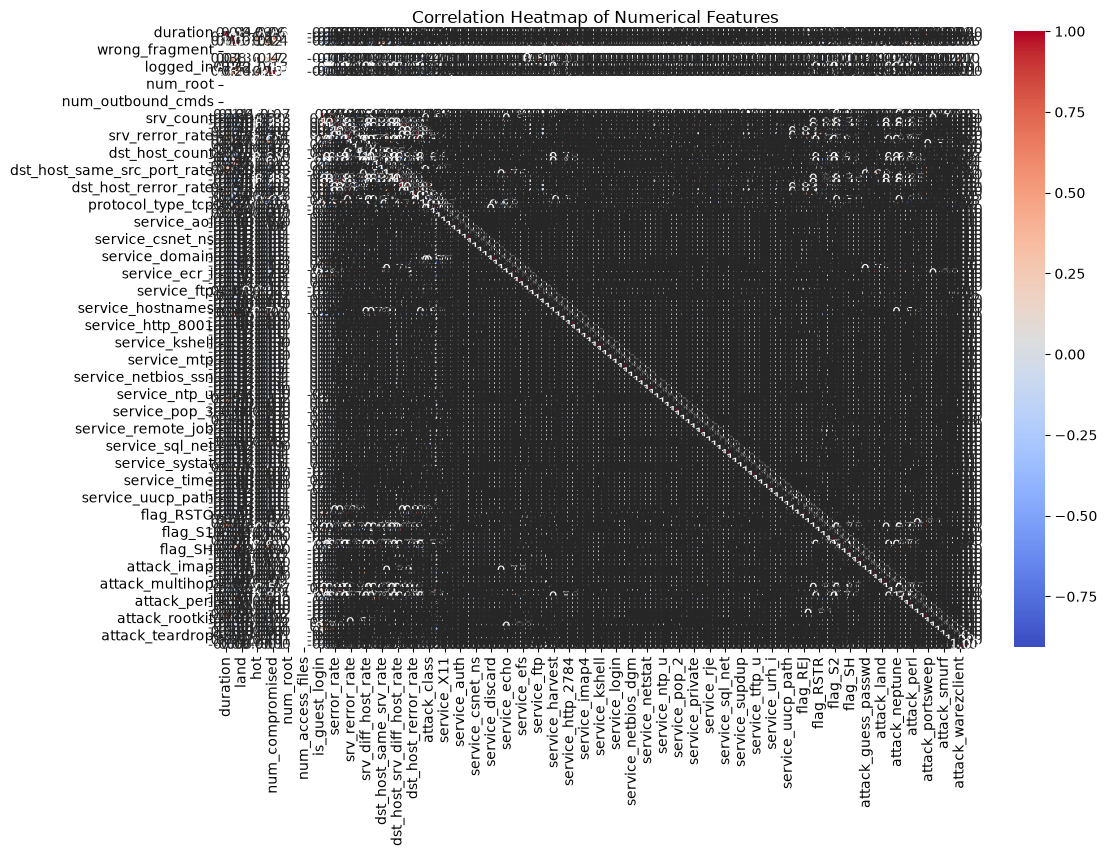

In [269]:
# visualize correlation matrix in Seaborn using a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corrm, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()
 

#Dropping columns based on data audit report
    - Based on low variance (near zero variance)
    - High missings (>25% missings)
    - High correlations between two numerical variables

In [270]:
train_new.drop(columns=['land', 'wrong_fragment', 'urgent', 'num_failed_logins', 'root_shell', 
                        'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 
                        'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
                        'dst_host_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_rerror_rate', 
                        'dst_host_srv_serror_rate', 'srv_rerror_rate', 'srv_serror_rate'], 
               inplace=True)

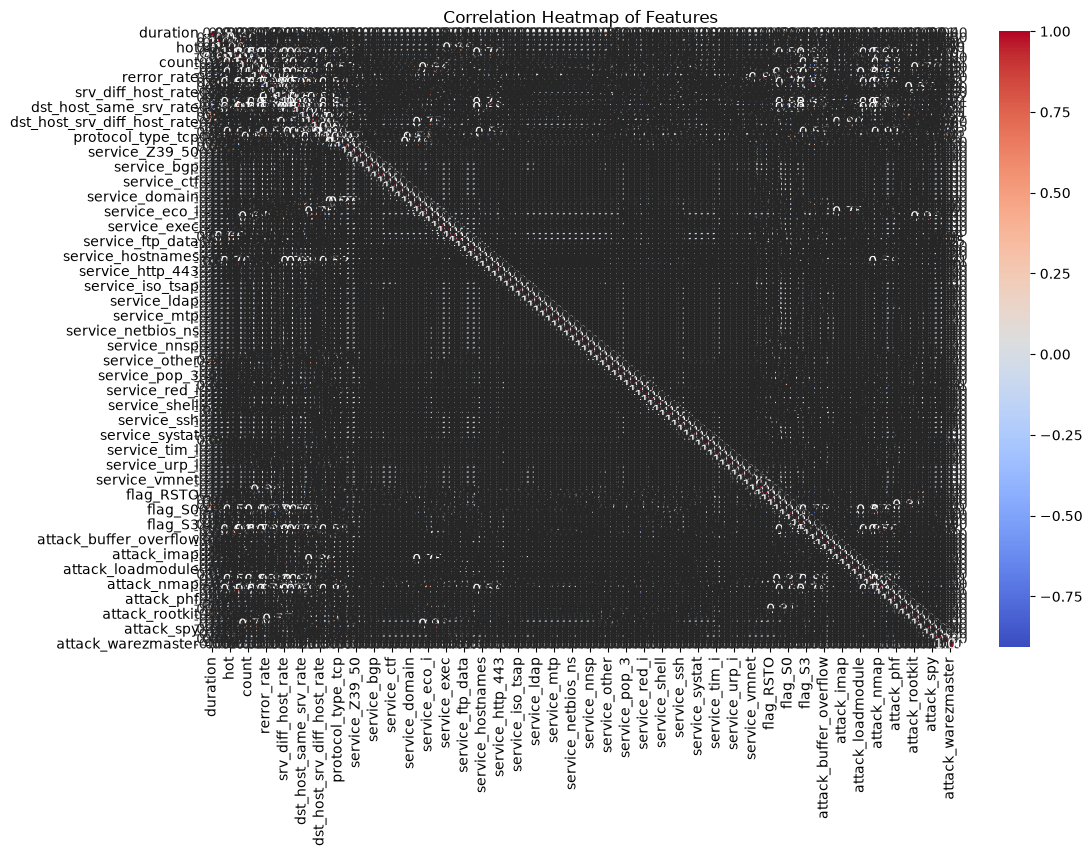

In [271]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(train_new.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()


In [272]:
#Variable reduction using Select K-Best technique

In [273]:
X = train_new[train_new.columns.difference(['attack_class'])]
X_new = SelectKBest(f_classif, k=15).fit(X, train_new['attack_class'] )

In [274]:
X_new.get_support()

array([False, False, False, False, False, False, False, False,  True,
       False,  True, False, False, False, False, False,  True, False,
       False, False, False, False,  True, False, False, False,  True,
        True,  True,  True, False, False, False, False, False, False,
        True, False, False, False,  True, False, False,  True,  True,
       False, False, False, False,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [275]:
X_new.scores_

array([1.34065299e+02, 3.56887917e+01, 2.37279329e+02, 4.90836877e+01,
       2.23884568e+04, 1.56918435e+01, 4.01530535e+01, 3.12252331e+01,
       3.49982737e+05, 7.54273339e+03,            inf, 1.33780279e+01,
       1.78387751e+01, 1.75926856e+02, 1.69866181e+04, 4.46180188e+01,
       2.26846808e+04, 2.44676269e+03, 8.91798303e+00, 7.92709355e+02,
       4.26682042e+03, 8.93063964e+01, 4.22705436e+04, 7.97243466e+03,
       5.76288566e+03, 1.85805841e+04, 2.24897554e+04, 2.75243035e+04,
       6.70289217e+04, 6.92391745e+04, 1.83321617e+04, 2.42925483e+03,
       2.92640418e+03, 6.10534447e+02, 4.62957625e+02, 1.01592923e+04,
       1.10261782e+05, 1.52319746e+02, 4.14800692e+01, 1.57818504e+01,
       1.10778397e+05, 1.21396798e+03, 1.29056823e+02, 3.23688064e+04,
       5.75742500e+04, 2.97257109e+02, 5.23057861e+03, 3.77788086e+03,
       8.06842874e+03, 1.33881495e+05, 1.02835005e+05, 2.34821159e+01,
       7.35347601e+02, 8.91798303e+00, 2.91634092e+02, 5.98598479e+02,
      

In [276]:
# capturing the important variables
KBest_features=X.columns[X_new.get_support()]
KBest_features

Index(['attack_neptune', 'attack_normal', 'attack_satan', 'count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_same_srv_rate', 'dst_host_srv_count', 'flag_S0', 'flag_SF',
       'last_flag', 'logged_in', 'same_srv_rate', 'serror_rate',
       'service_http'],
      dtype='str')

In [277]:
train=train_new
test=test_new

In [278]:
# Model Building nids

In [279]:
top_features=['attack_neptune','attack_normal','attack_satan','count','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_same_srv_rate','dst_host_srv_count','flag_S0','flag_SF','last_flag','logged_in','same_srv_rate','serror_rate','service_http']
X_train = train[top_features]
y_train = train['attack_class']
X_test = test[top_features]
y_test = test['attack_class']

In [280]:
# Building logistic Regression

In [281]:
import warnings
warnings.filterwarnings('ignore')

# Initialize and fit the model without the 'multi_class' argument
lr_clf = LogisticRegression(random_state=0, solver='lbfgs').fit(X_train, y_train)

In [282]:
y_pred=lr_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [283]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8352998580553584

In [284]:
# RidgeClassifier

In [285]:
from sklearn.linear_model import RidgeClassifier

In [286]:
rc_clf = RidgeClassifier().fit(X_train, y_train)

In [287]:
y_pred=rc_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 2., 0., 2.], shape=(22544,))

In [288]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.7606014904187367

In [289]:
# K-Nearest Neighbors

In [290]:
from sklearn.neighbors import KNeighborsClassifier

In [291]:
k_neigh = KNeighborsClassifier(n_neighbors=3)
k_neigh.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[float64](3,)","[0.,1.,2.]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [292]:
y_pred=k_neigh.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 0.], shape=(22544,))

In [293]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.7539921930447125

In [294]:
# NearestCentroid

In [295]:
from sklearn.neighbors import NearestCentroid


In [296]:
nc = NearestCentroid()
nc.fit(X_train, y_train)

,"metric metric: {""euclidean"", ""manhattan""}, default=""euclidean""Metric to use for distance computation.If `metric=""euclidean""`, the centroid for the samples corresponding to eachclass is the arithmetic mean, which minimizes the sum of squared L1 distances.If `metric=""manhattan""`, the centroid is the feature-wise median, whichminimizes the sum of L1 distances... versionchanged:: 1.5 All metrics but `""euclidean""` and `""manhattan""` were deprecated and now raise an error... versionchanged:: 0.19 `metric='precomputed'` was deprecated and now raises an error",'euclidean'
,"shrink_threshold shrink_threshold: float, default=NoneThreshold for shrinking centroids to remove features.",None
,"priors priors: {""uniform"", ""empirical""} or array-like of shape (n_classes,), default=""uniform""The class prior probabilities. By default, the class proportions areinferred from the training data... versionadded:: 1.6",'uniform'
Name,Type,Value
"centroids_ centroids_: array-like of shape (n_classes, n_features)Centroid of each class.","ndarray[float64](3, 15)","[[0. ,1. ,0. ,...,0.97,0.01,0.57], [0.9 ,0. ,0. ,...,0.19,0.75,0.05], [0. ,0. ,0.29,...,0.72,0.04,0. ]]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)The class prior probabilities... versionadded:: 1.6","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: array of shape (n_classes,)The unique classes labels.","ndarray[float64](3,)","[0.,1.,2.]"
"deviations_ deviations_: ndarray of shape (n_classes, n_features)Deviations (or shrinkages) of the centroids of each class from theoverall centroid. Equal to eq. (18.4) if `shrink_threshold=None`,else (18.5) p. 653 of [2]. Can be used to identify features usedfor classification... versionadded:: 1.6","ndarray[float64](3, 15)","[[-271.49, 643.41, -26.2 ,..., 223.98,-187.35, 140.92], [ 334.43,-522.32, -18.52,...,-240.73, 226.68,-110.31], [ -84.83,-230.92, 73.01,..., 13.77, -51.99, -57.12]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['attack_neptune','attack_normal','attack_satan',...,'same_srv_rate', 'serror_rate','service_http']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
"within_class_std_dev_ within_class_std_dev_: ndarray of shape (n_features,)Pooled or within-class standard deviation of input data... versionadded:: 1.6","ndarray[float64](15,)","[0.18,0. ,0.14,...,0.25,0.28,0.39]"


In [297]:
y_pred=nc.predict(X_test)
y_pred

array([1., 1., 2., ..., 0., 0., 2.], shape=(22544,))

In [298]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6059261887863733

In [299]:
#Discriminant Analysis

In [300]:
#1) LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [301]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train) 

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide <array_api>` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None
Name,Type,Value
"classes_ classes_: array-like of shape (n_classes,)Unique class labels.","ndarray[float64](3,)","[0.,1.,2.]"
"coef_ coef_: ndarray of shape (n_features,) or (n_classes, n_features)Weight vector(s).","ndarray[float64](3, 15)","[[-16.23, 0. , -3.51,..., -2.08, -0.07, -1.73], [ 26.57, -0. , -0.32,..., 4.07, 0.82, 3.27], [-10.02, -0. , 19.78,..., -3.71, -2.58, -2.63]]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If ``n_components`` is not set then all components are stored and thesum of explained variances is equal to 1.0. Only available when eigenor svd solver is used.","ndarray[float64](2,)","[0.81,0.19]"


In [302]:
y_pred=lda.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 0., 2.], shape=(22544,))

In [303]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7071504613200852

In [304]:
#2) QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [306]:
# Initialize QDA with a small regularization parameter
qda = QuadraticDiscriminantAnalysis(reg_param=0.01)

# Fit the model again
qda.fit(X_train, y_train)

,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.01
,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Unique class labels.","ndarray[float64](3,)","[0.,1.,2.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['attack_neptune','attack_normal','attack_satan',...,'same_srv_rate', 'serror_rate','service_http']"
"means_ means_: array-like of shape (n_classes, n_features)Class-wise means.","ndarray[float64](3, 15)","[[0. ,1. ,0. ,...,0.97,0.01,0.57], [0.9 ,0. ,0. ,...,0.19,0.75,0.05], [0. ,0. ,0.29,...,0.72,0.04,0. ]]"


In [307]:
y_pred=qda.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [308]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7991039744499645

In [309]:
# Decision Trees Algorithm

In [310]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import GridSearchCV
from sklearn import metrics


In [311]:
clf_tree = DecisionTreeClassifier( max_depth = 5)
clf_tree=clf_tree.fit( X_train, y_train )

In [312]:
y_pred=qda.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [313]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7991039744499645

In [314]:
#Fine Tuning the parameters

In [315]:
param_grid = {'max_depth': np.arange(3, 9),
             'max_features': np.arange(3,9)}

In [316]:
tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)
tree.fit( X_train, y_train )

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([3, 4, 5, 6, 7, 8]), 'max_features': array([3, 4, 5, 6, 7, 8])}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbos

In [317]:
tree.best_score_

np.float64(0.9983329691815761)

In [318]:
tree.best_estimator_

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(8)
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",np.int64(6)
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the n

In [319]:
tree.best_params_

{'max_depth': np.int64(8), 'max_features': np.int64(6)}

In [320]:
#Building Final Decision Tree Model

In [321]:
clf_tree = DecisionTreeClassifier( max_depth = 8, max_features=8 )
clf_tree.fit( X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",8
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

In [322]:
#Feature Relative Importance
clf_tree.feature_importances_

array([1.82138359e-01, 7.27732056e-01, 7.50360458e-03, 3.26322122e-02,
       1.16342997e-03, 5.90856297e-03, 2.29856214e-04, 2.43961449e-02,
       4.24408480e-04, 1.00735816e-04, 1.44973005e-02, 5.83463984e-05,
       1.40652953e-03, 2.75817618e-05, 1.78087178e-03])

In [323]:
# summarize the selection of the attributes
import itertools
feature_map = [(i, v) for i, v in itertools.zip_longest(X_train.columns, clf_tree.feature_importances_)]

feature_map

[('attack_neptune', np.float64(0.18213835913468335)),
 ('attack_normal', np.float64(0.7277320557255702)),
 ('attack_satan', np.float64(0.007503604582985678)),
 ('count', np.float64(0.032632212172719444)),
 ('dst_host_diff_srv_rate', np.float64(0.0011634299688603727)),
 ('dst_host_same_src_port_rate', np.float64(0.005908562967729604)),
 ('dst_host_same_srv_rate', np.float64(0.00022985621366867449)),
 ('dst_host_srv_count', np.float64(0.024396144923048504)),
 ('flag_S0', np.float64(0.00042440848037949744)),
 ('flag_SF', np.float64(0.00010073581574589933)),
 ('last_flag', np.float64(0.014497300545941156)),
 ('logged_in', np.float64(5.834639835059738e-05)),
 ('same_srv_rate', np.float64(0.0014065295329527756)),
 ('serror_rate', np.float64(2.7581761788172462e-05)),
 ('service_http', np.float64(0.0017808717755760995))]

In [324]:
Feature_importance = pd.DataFrame(feature_map, columns=['Feature', 'importance'])
Feature_importance.sort_values('importance', inplace=True, ascending=False)
Feature_importance

,Feature,importance
1,attack_normal,0.727732
0,attack_neptune,0.182138
3,count,0.032632
7,dst_host_srv_count,0.024396
10,last_flag,0.014497
2,attack_satan,0.007504
5,dst_host_same_src_port_rate,0.005909
14,service_http,0.001781
12,same_srv_rate,0.001407
4,dst_host_diff_srv_rate,0.001163


In [325]:
tree_test_pred = pd.DataFrame( { 'actual':  y_test,
                            'predicted': clf_tree.predict( X_test ) } )

In [326]:
tree_test_pred.sample( n = 10 )

,actual,predicted
808,1.0,2.0
14815,0.0,0.0
17620,0.0,0.0
12554,2.0,2.0
7052,1.0,1.0
21755,2.0,2.0
2813,0.0,0.0
11862,0.0,0.0
7890,0.0,0.0
19837,0.0,0.0


In [327]:
accuracy_score( tree_test_pred.actual, tree_test_pred.predicted )

0.8352998580553584

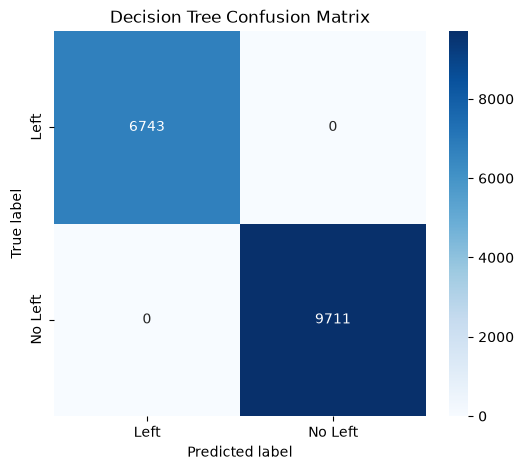

In [328]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
tree_cm = metrics.confusion_matrix(
    y_true=tree_test_pred.actual,
    y_pred=tree_test_pred.predicted,
    labels=[1, 0]  # must be keyword
)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(tree_cm, annot=True, fmt='d', 
            xticklabels=["Left", "No Left"], 
            yticklabels=["Left", "No Left"], cmap='Blues')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("Decision Tree Confusion Matrix")
plt.show()


In [329]:
#Naive Bayes Model

In [330]:
from sklearn.naive_bayes import BernoulliNB

In [331]:
bnb_clf = BernoulliNB()
bnb_clf.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[67343.,45927.,12703.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](3,)","[-0.63,-1.01,-2.29]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[float64](3,)","[0.,1.,2.]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 15)","[[ 0.,67343., 0.,...,67312., 2200.,38049.], [41214., 0., 0.,...,44927.,34524., 2255.], [ 0., 0., 3633.,...,10968., 2420., 34.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](3, 15)","[[-11.12, -0. ,-11.12,..., -0. , -3.42, -0.57], [ -0.11,-10.73,-10.73,..., -0.02, -0.29, -3.01], [ -9.45, -9.45, -1.25,..., -0.15, -1.66, -5.89]]"


In [332]:
y_pred=bnb_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 0., 0., 2.], shape=(22544,))

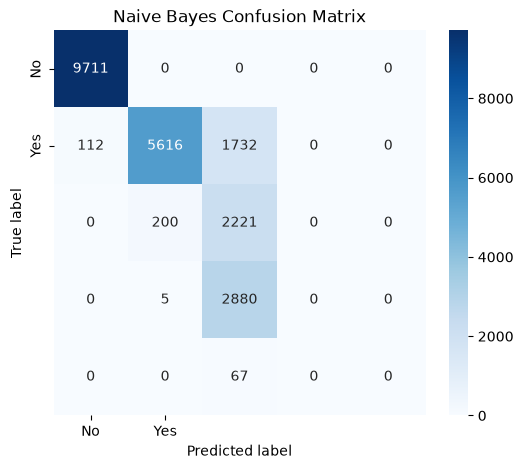

In [333]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
nb_cm = metrics.confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(nb_cm, annot=True, fmt='d',  # use 'd' for integer counts
            xticklabels=["No", "Yes"], 
            yticklabels=["No", "Yes"], cmap='Blues')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("Naive Bayes Confusion Matrix")
plt.show()


In [334]:
 accuracy_score( y_test, y_pred )

0.778388928317956

In [335]:
#2) GaussianNB
from sklearn.naive_bayes import GaussianNB

In [336]:
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[67343.,45927.,12703.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.53,0.36,0.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[float64](3,)","[0.,1.,2.]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.311e-05
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['attack_neptune','attack_normal','attack_satan',...,'same_srv_rate', 'serror_rate','service_http']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 15)","[[0. ,1. ,0. ,...,0.97,0.01,0.57], [0.9 ,0. ,0. ,...,0.19,0.75,0.05], [0. ,0. ,0.29,...,0.72,0.04,0. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 15)","[[0. ,0. ,0. ,...,0.02,0.01,0.25], [0.09,0. ,0. ,...,0.09,0.19,0.05], [0. ,0. ,0.2 ,...,0.18,0.03,0. ]]"


In [337]:
y_pred=gnb_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

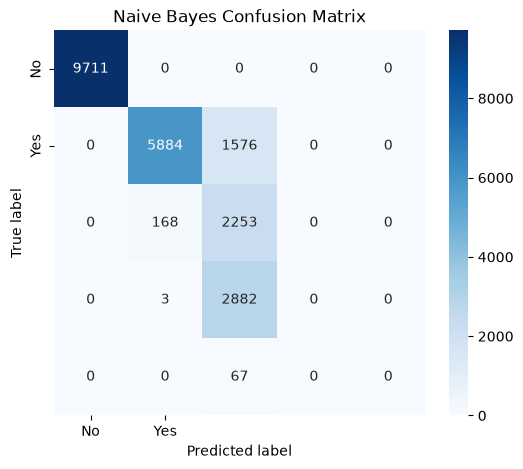

In [338]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
nb_cm = metrics.confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(nb_cm, annot=True, fmt='d',  # use 'd' for integers
            xticklabels=["No", "Yes"], 
            yticklabels=["No", "Yes"], cmap='Blues')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title("Naive Bayes Confusion Matrix")
plt.show()


In [339]:
accuracy_score( y_test, y_pred )

0.7916962384669979

In [340]:
 #Support Vector Machine (SVM)

In [341]:
#1) LinearSVC
from sklearn.svm import LinearSVC

In [342]:
svm_clf = LinearSVC(random_state=0, tol=1e-5)
svm_clf.fit(X_train, y_train)

,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjus

In [343]:
y_pred=svm_clf.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [344]:
accuracy_score( y_test, y_pred )

0.8368523775727467

In [345]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [346]:
model = SGDClassifier(loss="hinge", penalty="l2")
model.fit(X_train, y_train)

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if th

In [347]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [348]:
accuracy_score( y_test, y_pred )

0.7865951029098651

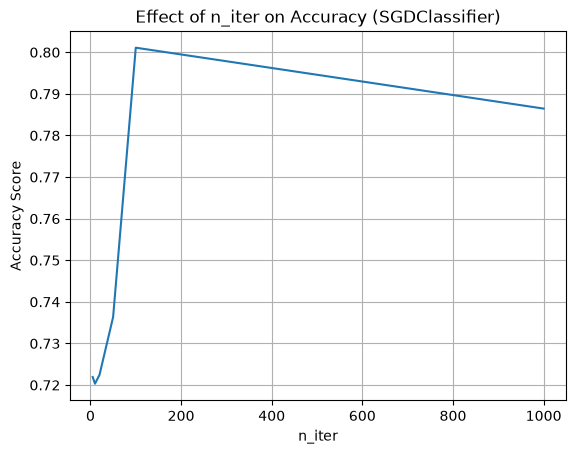

In [349]:
 #  List of different iteration counts
n_iters = [5, 10, 20, 50, 100, 1000]
scores = []

# Train model with different n_iter values
for n_iter in n_iters:
    model = SGDClassifier(loss="hinge", penalty="l2", max_iter=n_iter)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

# Plot results
plt.title("Effect of n_iter on Accuracy (SGDClassifier)")
plt.xlabel("n_iter")
plt.ylabel("Accuracy Score")
plt.plot(n_iters, scores)
plt.grid()       # optional, to make graph clearer
plt.show()


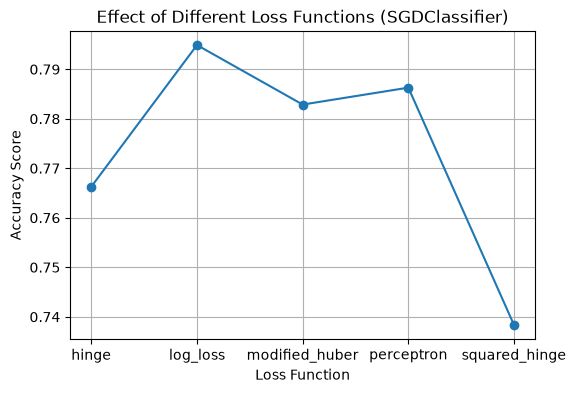

In [350]:
#Different loss functions to compare
losses = ["hinge", "log_loss", "modified_huber", "perceptron", "squared_hinge"]
scores = []

for loss in losses:
    model = SGDClassifier(loss=loss, penalty="l2", max_iter=1000)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

#  Plot
plt.figure(figsize=(6,4))
plt.xlabel("Loss Function")
plt.ylabel("Accuracy Score")
plt.title("Effect of Different Loss Functions (SGDClassifier)")
x = np.arange(len(losses))
plt.xticks(x, losses)
plt.plot(x, scores, marker='o')  # marker added to show points
plt.grid()
plt.show()


In [351]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
scaler = StandardScaler()
# Fit only to the training data
scaler.fit(X_train)

StandardScaler()

In [352]:
# Now apply the transformations to the data:
train_X = scaler.transform(X_train)
test_X = scaler.transform(X_test)

In [353]:
mlp = MLPClassifier(hidden_layer_sizes=(30,30,30))
mlp.fit(train_X,y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(30, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


In [354]:
y_pred=mlp.predict(test_X)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [355]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[9707    0    4    0    0]
 [   0 6820  640    0    0]
 [   0  338 2083    0    0]
 [   0  527 2358    0    0]
 [   0    0   67    0    0]]


In [356]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9711
         1.0       0.89      0.91      0.90      7460
         2.0       0.40      0.86      0.55      2421
         3.0       0.00      0.00      0.00      2885
         4.0       0.00      0.00      0.00        67

    accuracy                           0.83     22544
   macro avg       0.46      0.55      0.49     22544
weighted avg       0.77      0.83      0.79     22544



In [357]:
mlp.coefs_

[array([[-0.20056924, -0.14742246,  0.15780033,  0.41624726, -0.16068731,
          0.4936377 ,  0.06823063, -0.13851115, -0.04973819, -0.31880082,
         -0.0474588 ,  0.88644311,  0.02848531,  0.04773325,  0.05176587,
         -0.0979955 ,  0.20554024, -0.23507438,  0.41447081, -0.22696251,
          0.23490974, -0.35218158,  0.12272074, -0.45766351,  0.06393638,
         -0.35403341, -0.47894594, -0.29403906,  0.73177835,  0.41518402],
        [-0.08729875,  0.27238338, -0.47012731, -0.6016301 ,  0.30059802,
          0.08894661, -0.08142698, -0.45406116,  0.30598693, -0.27797263,
          0.22633088, -0.11657505,  0.14385234,  0.32737741, -0.28928458,
         -0.55131259, -0.14103   ,  0.01351649,  0.71150396, -0.45104203,
         -0.20128737, -0.11620471, -0.22886709,  0.30629458,  0.79248242,
          0.3741339 ,  0.40268731, -0.40129945,  0.20310936,  0.03783556],
        [ 0.01250208, -0.13928078, -0.31870946,  0.07132489,  0.26473698,
          0.07366522, -0.36023908,  

In [358]:
#1. Bagged Decision Trees
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [359]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
import numpy as np

seed = 7
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

cart = DecisionTreeClassifier()
num_trees = 100

model = BaggingClassifier(
    estimator=cart,          #  replaced base_estimator with estimator
    n_estimators=num_trees,
    random_state=seed
)

results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Average Accuracy:", results.mean())
print("All CV scores:", results)


Average Accuracy: 0.9993570048826251
All CV scores: [0.99960311 0.9992856  0.99920622 0.99960308 0.99944431 0.99928554
 0.99976185 0.99920616 0.99872986 0.99944431]


In [360]:
model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",7
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [361]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [362]:
accuracy_score( y_test, y_pred )

0.8117459190915542

In [363]:
#2)Random forest

In [364]:
from sklearn.ensemble import RandomForestClassifier

In [365]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

seed = 7
num_trees = 100
max_features = 3

kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

model = RandomForestClassifier(
    n_estimators=num_trees,
    max_features=max_features,
    random_state=seed
)

results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Average Accuracy:", results.mean())
print("All Fold Scores:", results)


Average Accuracy: 0.9994998928965302
All Fold Scores: [0.99960311 0.99952373 0.99936498 0.99960308 0.99936493 0.99944431
 0.99984123 0.99944431 0.99928554 0.9995237 ]


In [366]:
model.fit(X_train, y_train)


,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bo

In [367]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [368]:
accuracy_score( y_test, y_pred )


0.8183995741660752

In [369]:
#3. Extra Trees
from sklearn.ensemble import ExtraTreesClassifier

In [370]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import ExtraTreesClassifier
import warnings
warnings.filterwarnings("ignore")

seed = 7
num_trees = 100
max_features = 7

# Shuffle=True avoids warnings & gives better folds
kfold = KFold(n_splits=10, shuffle=True, random_state=seed)

model = ExtraTreesClassifier(
    n_estimators=num_trees,
    max_features=max_features,
    random_state=seed,
    class_weight='balanced'
)

results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Average Accuracy:", results.mean())
print("All Fold Scores:", results)


Average Accuracy: 0.9994919538683673
All Fold Scores: [0.99944436 0.99968249 0.99944436 0.99936493 0.99928554 0.99920616
 0.99968246 0.99960308 0.99960308 0.99960308]


In [371]:
model.fit(X_train, y_train)

,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",7
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node

In [372]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [373]:
accuracy_score( y_test, y_pred )

0.8038502484031228

In [374]:
#Boosting Algorithms

In [375]:
#. AdaBoost
from sklearn.ensemble import AdaBoostClassifier

In [376]:
from sklearn import model_selection
from sklearn.ensemble import AdaBoostClassifier

seed = 7
num_trees = 30

kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)
model = AdaBoostClassifier(n_estimators=num_trees, random_state=seed)

results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print("AdaBoost Accuracy (10-Fold):", results.mean())


AdaBoost Accuracy (10-Fold): 0.9954196451570108


In [377]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",30
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",7
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[float64](3,)","[0.,1.,2.]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](30,)","[0.1 ,0.14,0.14,...,0.29,0.38,0.28]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](30,)","[2.88,2.55,2.47,...,1.58,1.18,1.63]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...ate=327741615), DecisionTreeC...ate=976413892), DecisionTreeC...te=1202242073), DecisionTreeC...te=1369975286), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](15,)","[0.05,0.62,0.04,...,0.03,0. ,0. ]"


In [378]:
y_pred=model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 0., 2.], shape=(22544,))

In [379]:
accuracy_score( y_test, y_pred )

0.8156937544357701

In [380]:
#Save Model

In [381]:
import pickle
# Saving model to disk of random forest
pickle.dump(lr_clf, open('model1.pkl','wb'))

In [382]:
#Load Model and Predict

In [383]:
import pickle
model=pickle.load(open('model1.pkl', 'rb'))
model.predict([[1,0,0,229,0.06,0.00,0.04,10,0,0,21,0,0.04,0.00,0]])

array([1.])

In [385]:
# ---------------- SYSTEM ----------------
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import warnings
warnings.filterwarnings("ignore")

# ---------------- IMPORTS ----------------
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from collections import Counter

# ---------------- COMMON ----------------
columns = [f"f{i}" for i in range(41)] + ["label", "difficulty"]

def clean(y):
    return y.astype(str).str.strip().str.replace(r'\.$', '', regex=True).str.lower()

attack_map = {
    'normal': 0,
    'neptune': 1, 'smurf': 1, 'back': 1, 'teardrop': 1, 'pod': 1, 'land': 1,
    'ipsweep': 2, 'nmap': 2, 'portsweep': 2, 'satan': 2,
    'ftp_write': 3, 'guess_passwd': 3, 'imap': 3, 'multihop': 3,
    'phf': 3, 'spy': 3, 'warezclient': 3, 'warezmaster': 3,
    'buffer_overflow': 4, 'loadmodule': 4, 'perl': 4, 'rootkit': 4
}

# ---------------- LOAD TRAIN ----------------
train_df = pd.read_csv("KDDTrain.csv", header=None)
train_df.columns = columns
train_df.drop("difficulty", axis=1, inplace=True)
train_df = train_df.replace([np.inf, -np.inf], np.nan).fillna(0)

X = train_df.drop("label", axis=1)
y = clean(train_df["label"]).map(attack_map)

mask = y.notnull()
X, y = X[mask], y[mask].astype(int)

# ---------------- ENCODING ----------------
categorical_cols = ["f1", "f2", "f3"]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# ---------------- SPLIT ----------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------- SCALING ----------------
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# ---------------- BALANCING (BEST FIX) ----------------
print("Before balance:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After balance:", Counter(y_train))

# ---------------- CLASS WEIGHTS ----------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weight_dict = {i: w for i, w in enumerate(class_weights)}
sample_weights = np.array([weight_dict[y] for y in y_train])

# ---------------- MODEL (FINAL XGBOOST) ----------------
model = XGBClassifier(
    n_estimators=350,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.6,
    reg_lambda=2.5,
    gamma=0.1,
    min_child_weight=2,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=4
)

print("🚀 Training Advanced XGBoost...")
model.fit(X_train, y_train, sample_weight=sample_weights)

# ---------------- VALIDATION ----------------
val_probs = model.predict_proba(X_val)
y_val_pred = np.argmax(val_probs, axis=1)

print("\n📊 VALIDATION")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# ---------------- LOAD TEST ----------------
test_df = pd.read_csv("KDDTest.csv", header=None)
test_df.columns = columns
test_df.drop("difficulty", axis=1, inplace=True)
test_df = test_df.replace([np.inf, -np.inf], np.nan).fillna(0)

X_test = test_df.drop("label", axis=1)
y_test = clean(test_df["label"]).map(attack_map)

mask = y_test.notnull()
X_test, y_test = X_test[mask], y_test[mask].astype(int)

# ---------------- ENCODE TEST ----------------
for col, enc in encoders.items():
    X_test[col] = X_test[col].astype(str)
    X_test[col] = X_test[col].apply(
        lambda x: x if x in enc.classes_ else enc.classes_[0]
    )
    X_test[col] = enc.transform(X_test[col])

# ---------------- SCALE TEST ----------------
X_test = scaler.transform(X_test)

# ---------------- TEST PREDICT ----------------
test_probs = model.predict_proba(X_test)
y_test_pred = np.argmax(test_probs, axis=1)

print("\n🔥 TEST")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
print("Distribution:", Counter(y_test_pred))

# ---------------- SAVE ----------------
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("\n✅ FINAL MODEL SAVED SUCCESSFULLY")

Before balance: Counter({0: 53874, 1: 36741, 2: 9325, 3: 796, 4: 42})
After balance: Counter({1: 53874, 0: 53874, 2: 53874, 3: 53874, 4: 53874})
🚀 Training Advanced XGBoost...

📊 VALIDATION
Accuracy: 0.9991665012899384
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00      9186
           2       1.00      1.00      1.00      2331
           3       0.98      0.99      0.98       199
           4       0.90      0.90      0.90        10

    accuracy                           1.00     25195
   macro avg       0.97      0.98      0.98     25195
weighted avg       1.00      1.00      1.00     25195


🔥 TEST
Accuracy: 0.8788975204852613
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      9711
           1       0.99      0.99      0.99      5741
           2       0.79      1.00      0.88      1106
           3       0.99      0.12     

In [1]:
# ---------------- IMPORTS ----------------
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
import xgboost as xgb


# ---------------- LOAD DATA ----------------
train = pd.read_csv("KDDTrain.csv", header=None) 
test = pd.read_csv("KDDTest.csv", header=None)

# FIX column mismatch
test.columns = train.columns

# ---------------- ATTACK LABEL FIX ----------------
def map_attack(label):
    if label == "normal":
        return 0
    elif label in ["neptune","smurf","back","teardrop","pod","land"]:
        return 1
    elif label in ["satan","ipsweep","nmap","portsweep"]:
        return 2
    elif label in ["guess_passwd","ftp_write","imap","phf","multihop","warezmaster","warezclient"]:
        return 3
    else:
        return 4

# 1. Drop the last_flag (difficulty) column
train = train.iloc[:, :-1]
test = test.iloc[:, :-1]

# 2. APPLY THE FUNCTION TO THE TARGET COLUMN SAFELY
# Using the column name directly allows the dtype to change from string to integer
train[train.columns[-1]] = train.iloc[:, -1].apply(map_attack)
test[test.columns[-1]] = test.iloc[:, -1].apply(map_attack)

# ---------------- ENCODING (FIXED) ----------------
categorical_cols = train.select_dtypes(include='object').columns
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

for col in categorical_cols:
    le = encoders[col]
    test[col] = test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    test[col] = le.transform(test[col])


# ---------------- SPLIT ----------------
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]


# ---------------- SMOTE ----------------
print("\nBefore SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train).value_counts())


# ---------------- SCALING ----------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ---------------- MODELS ----------------
# ---------------- MODELS (OPTIMIZED) ----------------
models = {
    # Added n_jobs=-1 to utilize all available CPU cores for faster training
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss', n_estimators=100, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Naive Bayes": GaussianNB()
    # SVC(kernel='rbf') has been temporarily removed
}


# ---------------- TRAIN + EVALUATE ----------------
results = []

for name, model in models.items():
    print("\n====================================")
    print("🚀 Training:", name)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))

    results.append([name, acc, prec, rec, f1])


# ---------------- FINAL RESULT ----------------
results_df = pd.DataFrame(results, columns=[
    "Algorithm", "Accuracy", "Precision", "Recall", "F1 Score"
])

print("\n================ FINAL COMPARISON ================\n")
print(results_df.sort_values(by="Accuracy", ascending=False).to_string(index=False))


# ---------------- BEST MODEL ----------------
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Algorithm"]

print("\n BEST MODEL:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\n📄 CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))


# ---------------- SAVE ----------------
results_df.to_csv("model_results.csv", index=False)
print("\n✅ Saved: model_results.csv")

C:\Users\Sarvadnya\AppData\Local\Temp\ipykernel_9728\812397546.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include='object').columns



Before SMOTE:
 41
0    67343
1    45927
2    11656
3      993
4       55
Name: count, dtype: int64

After SMOTE:
 41
4    67343
0    67343
1    67343
3    67343
2    67343
Name: count, dtype: int64

🚀 Training: XGBoost
Accuracy : 0.7367
Precision: 0.7863
Recall   : 0.7367
F1 Score : 0.6525

🚀 Training: Random Forest
Accuracy : 0.7285
Precision: 0.7923
Recall   : 0.7285
F1 Score : 0.6342

🚀 Training: Decision Tree
Accuracy : 0.7136
Precision: 0.6432
Recall   : 0.7136
F1 Score : 0.6175

🚀 Training: Logistic Regression


c:\Users\Sarvadnya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy : 0.7261
Precision: 0.677
Recall   : 0.7261
F1 Score : 0.6664

🚀 Training: Naive Bayes
Accuracy : 0.4074
Precision: 0.4778
Recall   : 0.4074
F1 Score : 0.3118

================ FINAL COMPARISON ================

          Algorithm  Accuracy  Precision   Recall  F1 Score
            XGBoost  0.736704   0.786334 0.736704  0.652493
      Random Forest  0.728543   0.792273 0.728543  0.634250
Logistic Regression  0.726103   0.676965 0.726103  0.666444
      Decision Tree  0.713595   0.643224 0.713595  0.617459
        Naive Bayes  0.407407   0.477813 0.407407  0.311807

 BEST MODEL: XGBoost

📄 CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.96      1.00      0.98      5741
           2       0.49      1.00      0.66      1106
           3       0.98      0.16      0.27      2199
           4       0.79      0.01      0.01      3788

    accuracy                           0.74 